In [98]:
import numpy as np
import scipy.linalg as linalg
import matplotlib.pyplot as plt


In [99]:
def gaussian3d(x,mean,covar = np.array([[5,0,0],[0,5,0],[0,0,5]])):

    '''
    returns a 3d gaussian evaluated for an image and time location with a given covariance matrix and mean
    '''
    

    Ninv = np.linalg.pinv(covar)

    #return np.exp(-np.diag((x-mean).T@Ninv@(x-mean))) ## there's probably a smarter way to do this
    #Normalized: 

    return ((2*np.pi)**-1.5)*(np.linalg.det(covar)**-0.5)*np.exp(-0.5*np.diag((x-mean).T@Ninv@(x-mean)))


def genrandomfield(xlen,ylen,tlen,Ntrans,widths = None,noiseamp = 0.1):

    '''
    generates a field of white noise with a given number of overlaid gaussian 'transients'.
    Transients and noise returned as separate layers. 

    Arguements (in order):

    xlen: length of the first image dimension, in pixels
    ylen: same as above but for second dimension
    tlen: length of the image/noise fields to be generated, in time (arbitrary units)
    Ntrans: how many transients to simulate
    widths: a 3-tuple (A,B,C) of sigma values corresponding to the x, y and time widths of the 3D Gaussian transients.
    for example, widths = (1,2,10) will give transients that are narrow in the first image dimension, broader in the second,
    and have a characteristic timescale of about 10 time units.
    noiseamp: the root-mean-square level of (white) noise in the image.

    returns: (in order)

    noisefield: the noise layer, with shape (xlen,ylen,tlen)
    transient_field: the transient layer, with shape (xlen,ylen,tlen)
    x0: the list of positions of each source in the first image axis
    y0: the list of positions of each source in the second image axis
    t0: the central times of each transient signal (time of peak brightness)
    '''

    x = np.arange(xlen) ## x and y arrays
    y = np.arange(ylen)

    xx,yy = np.meshgrid(x,y) ## create a grid of x,y positions to evaluate at

    xxf,yyf = xx.ravel(),yy.ravel() ## flatten for processing

    rng = np.random.default_rng()

    noisefield = noiseamp*rng.standard_normal(size = (xlen,ylen,tlen)) # generate the noise

    transient_field = np.zeros(noisefield.shape) ## array for the transient layer to be created in

    x0 = [] ## these record the x, y, and time mean values for each transient signal
    y0 = [] ## these record the x, y, and time mean values for each transient signal
    t0 = [] ## these record the x, y, and time mean values for each transient signal

    posvecs = np.zeros((3,len(xxf)))
    posvecs[0,:] = xxf
    posvecs[1,:] = yyf

    if widths:

        covar = np.array([[widths[0]**2,0,0],[0,widths[1]**2,0],[0,0,widths[2]**2]])
    
    for i in range(Ntrans):

        x0.append(np.random.randint(xlen)) ## record where this trans happened
        y0.append(np.random.randint(ylen))
        t0.append(np.random.randint(tlen))

        for t in range(tlen):

            posvecs[2,:] = t

            if widths:

                trans = gaussian3d(posvecs, mean = np.array([[x0[-1],y0[-1],t0[-1]]]).T, covar = covar).reshape((xlen,ylen))

            else:

                trans = gaussian3d(posvecs, mean = np.array([[x0[-1],y0[-1],t0[-1]]]).T).reshape((xlen,ylen))

            transient_field[:,:,t] += trans

    return noisefield,transient_field,x0,y0,t0

In [ ]:
n,t,x0,y0,t0 = genrandomfield(50,50,100,5, widths = (5,5,10), noiseamp=1e-10)

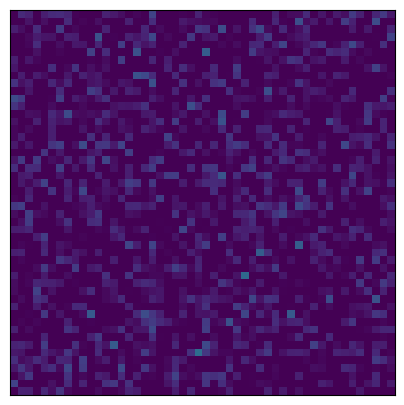

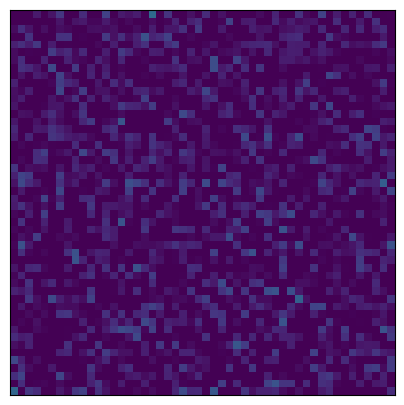

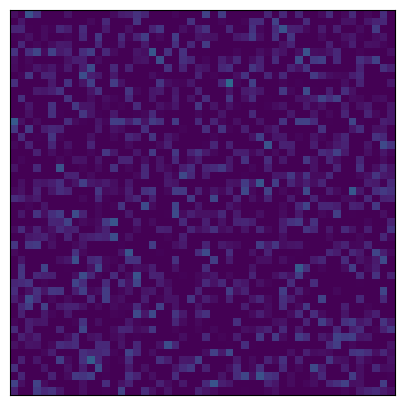

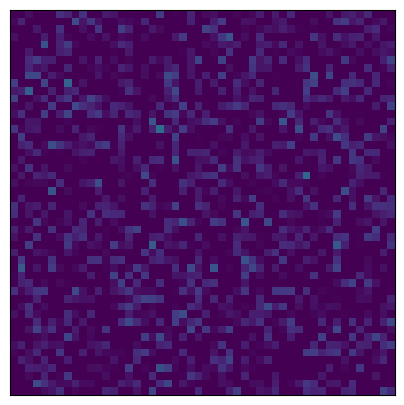

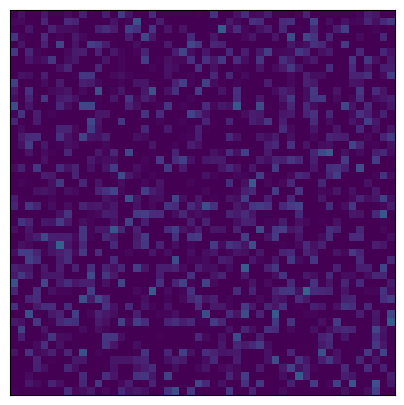

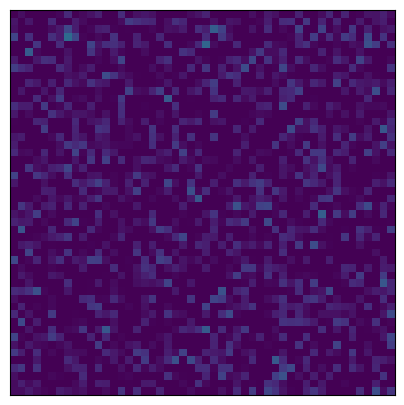

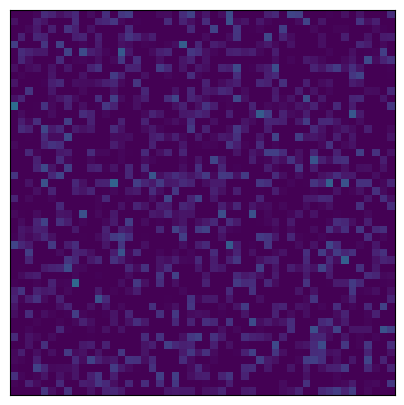

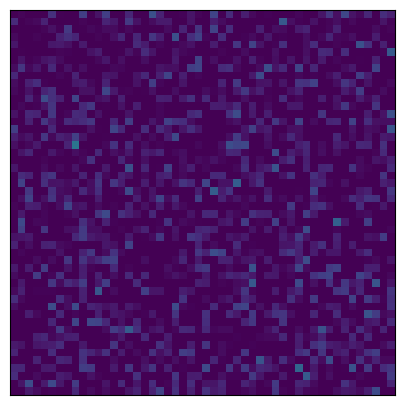

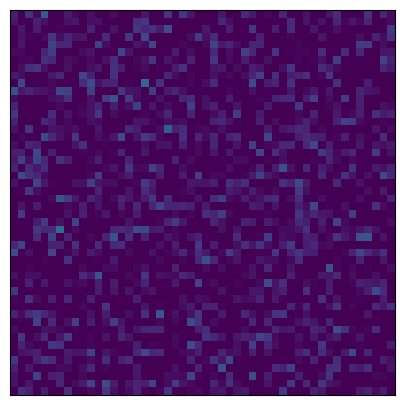

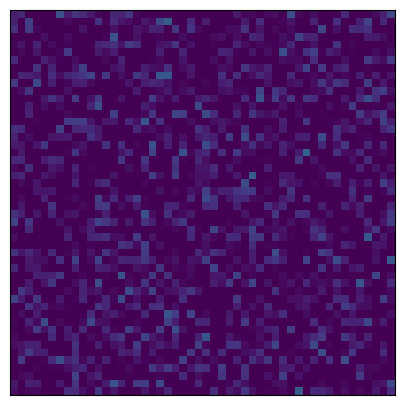

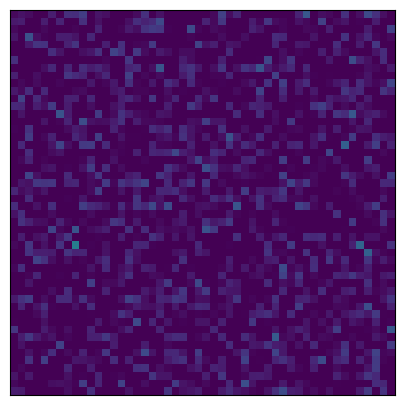

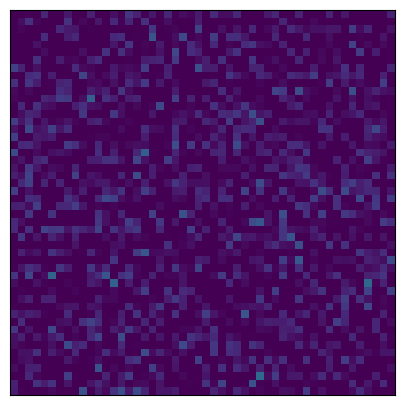

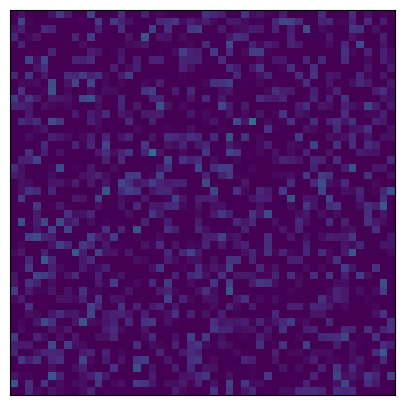

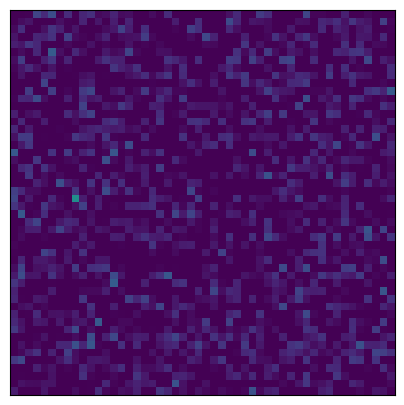

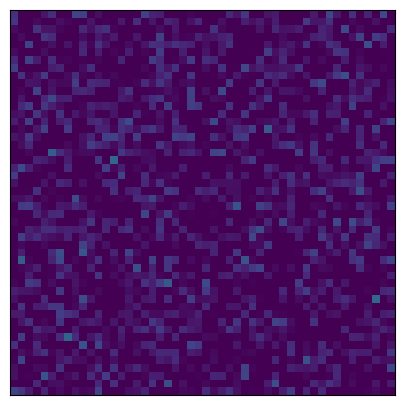

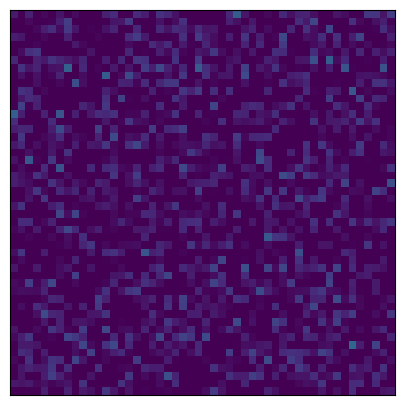

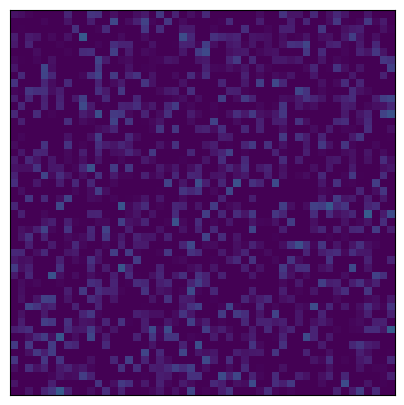

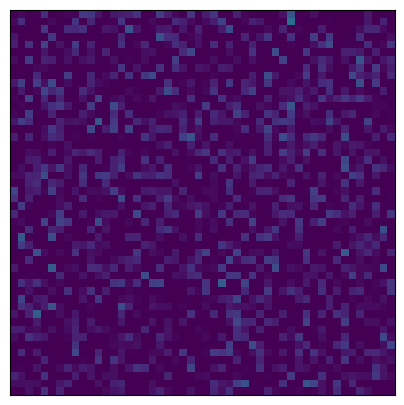

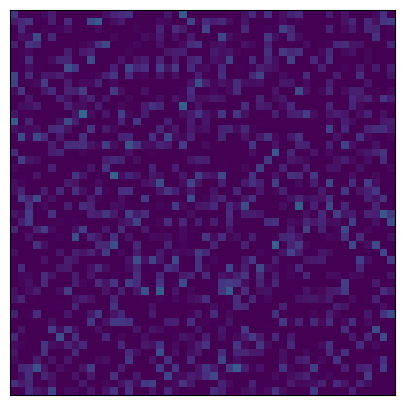

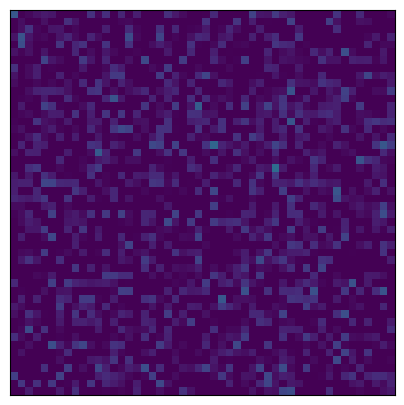

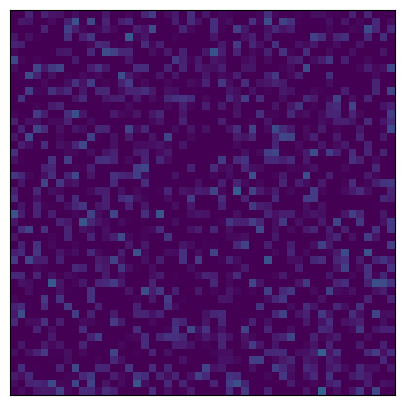

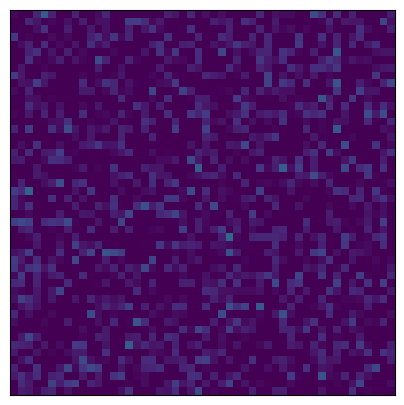

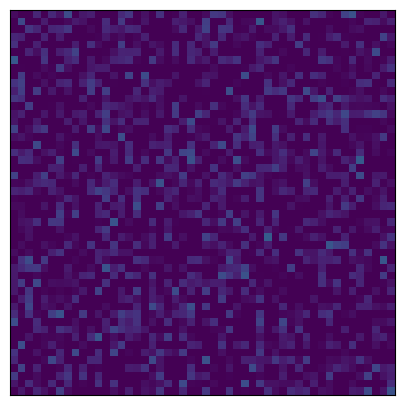

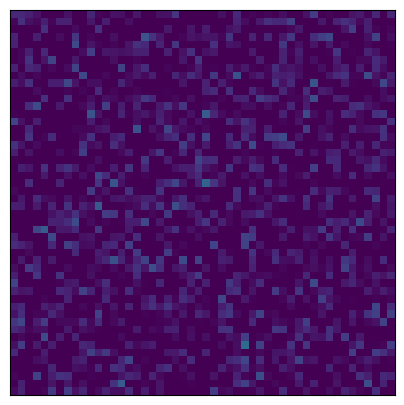

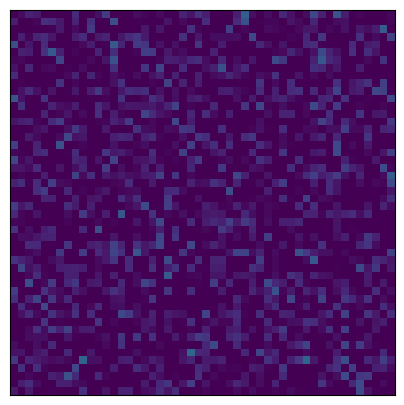

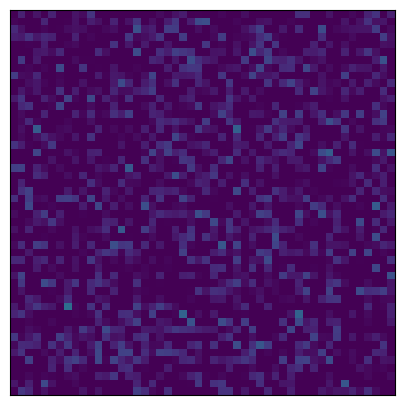

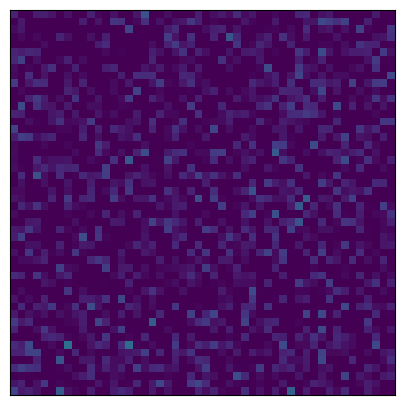

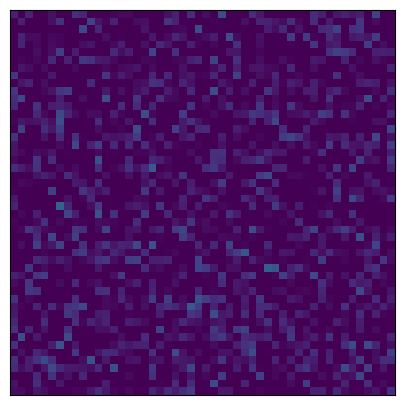

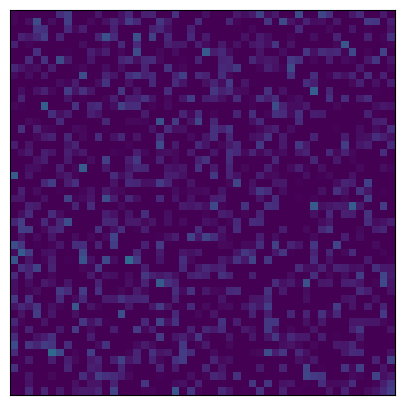

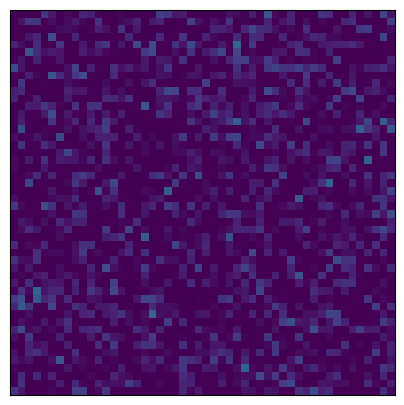

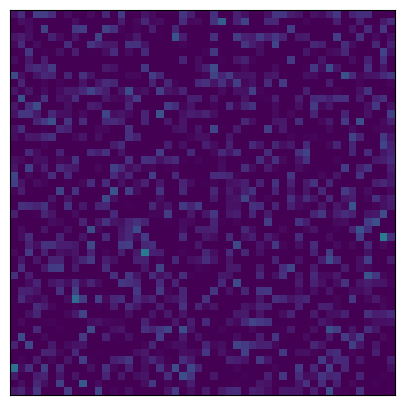

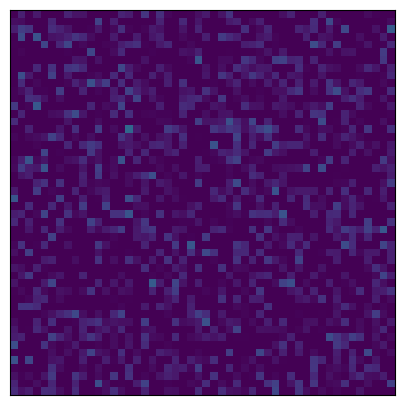

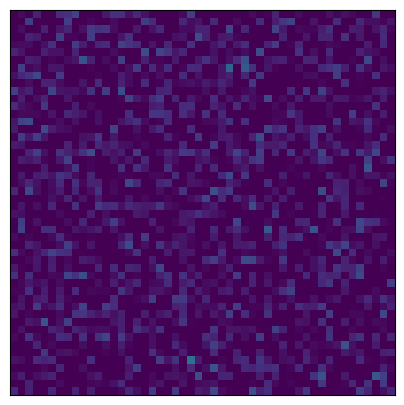

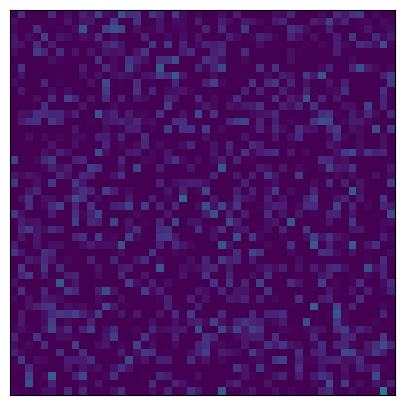

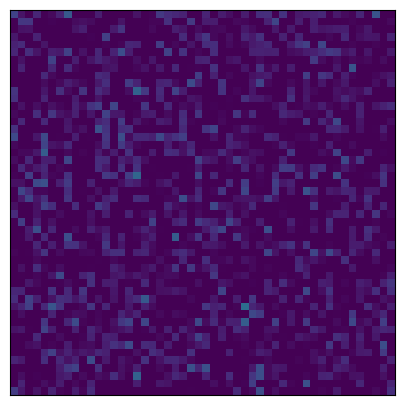

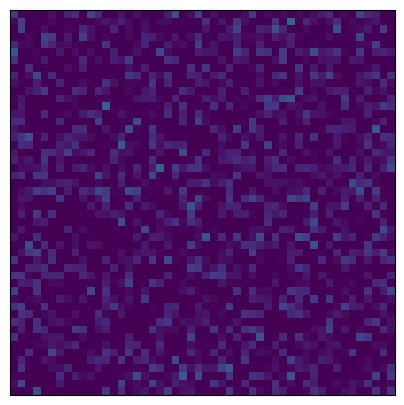

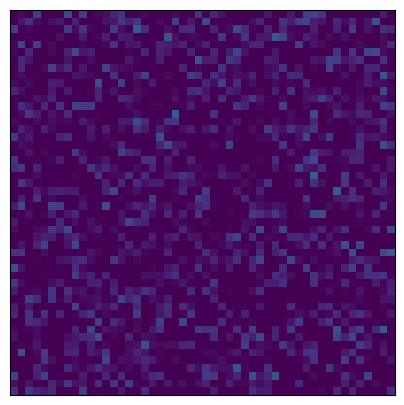

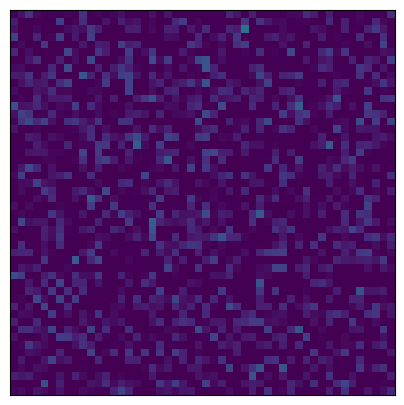

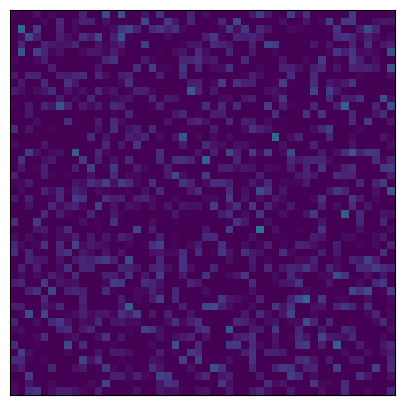

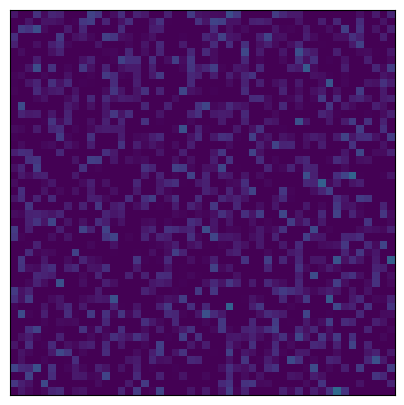

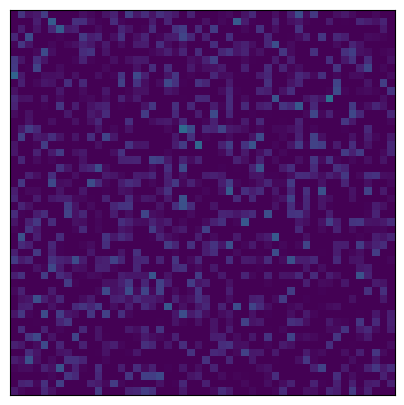

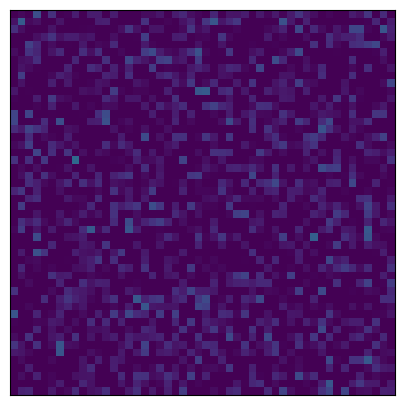

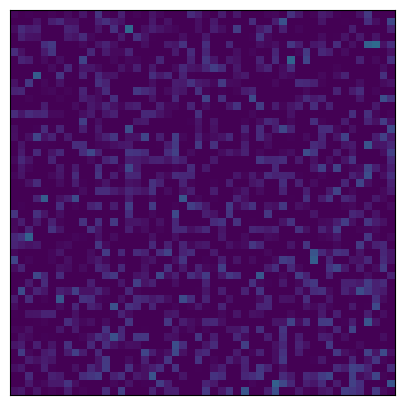

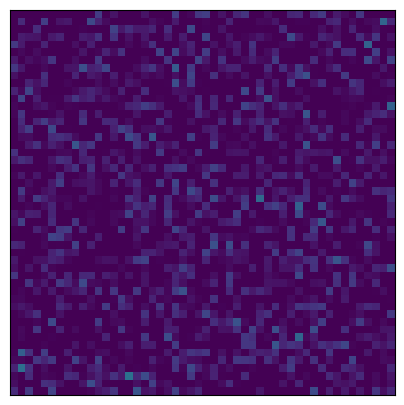

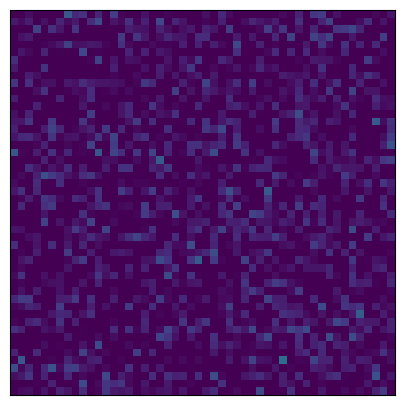

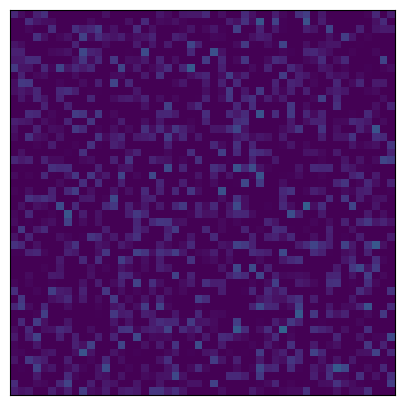

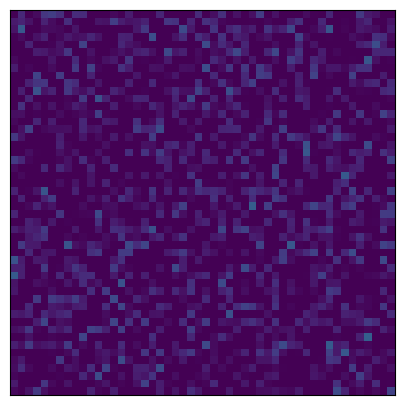

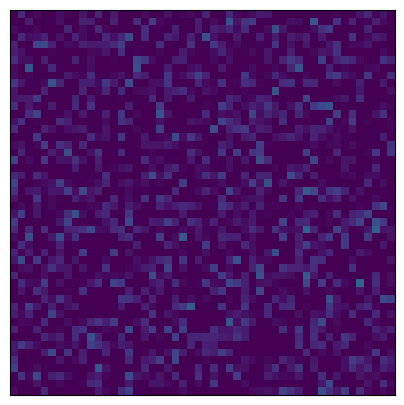

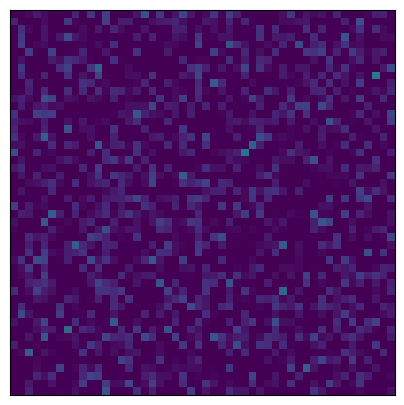

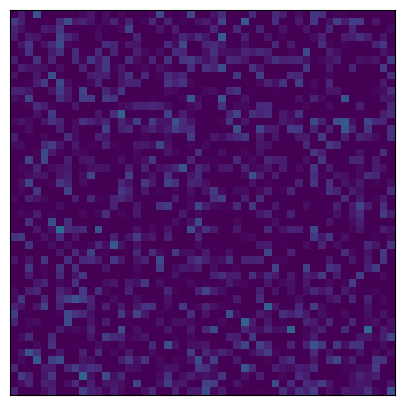

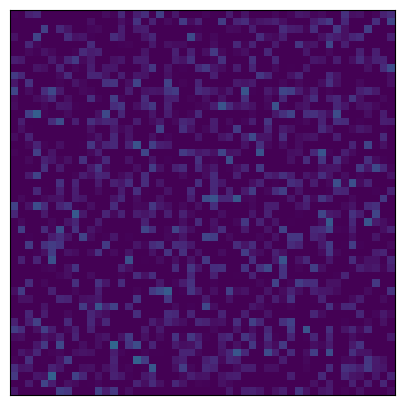

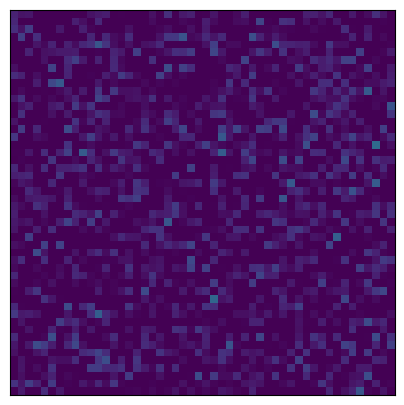

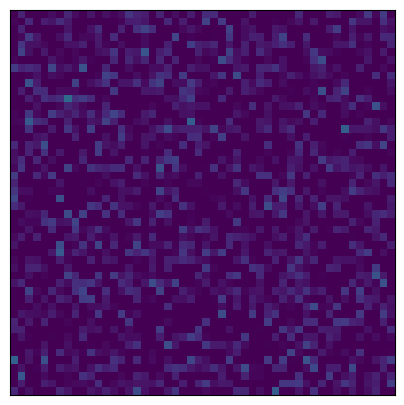

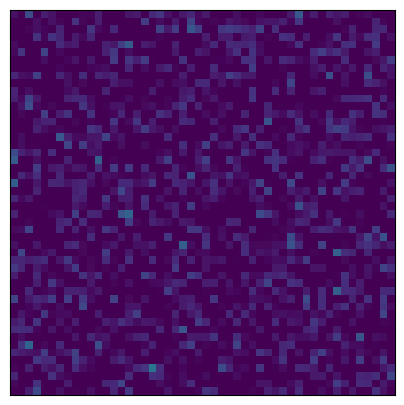

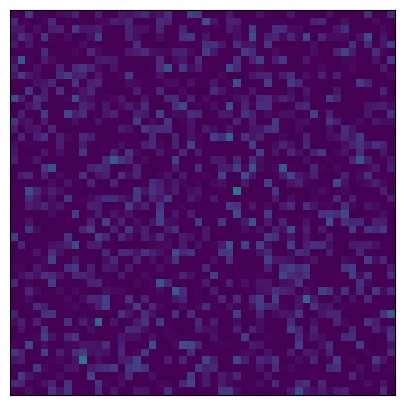

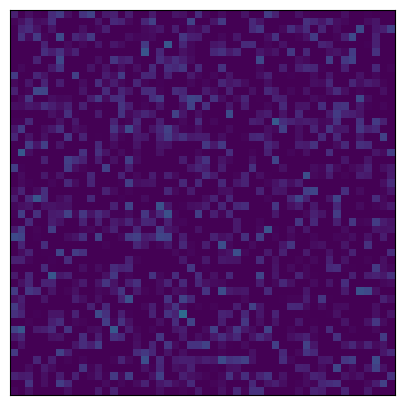

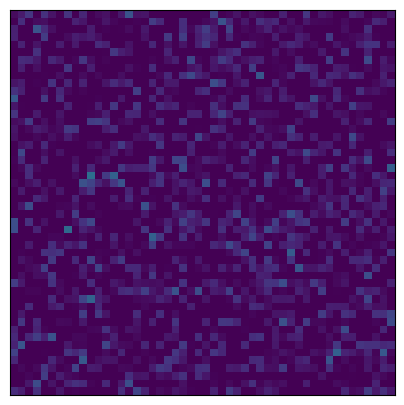

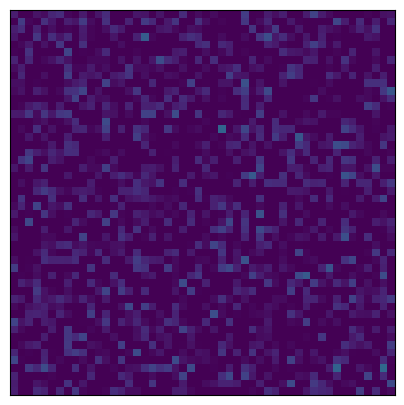

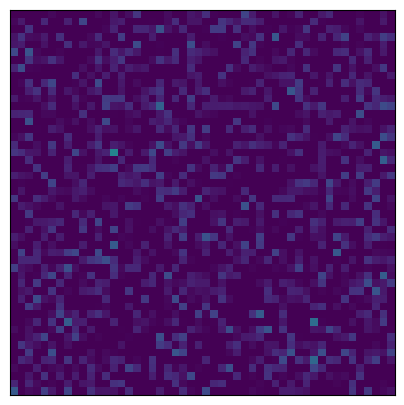

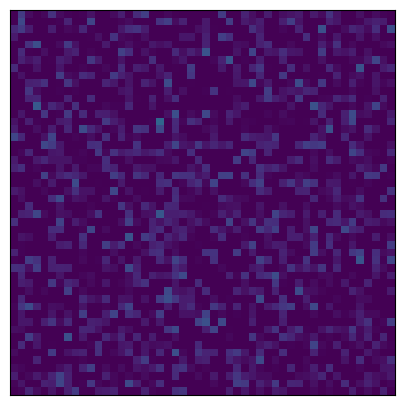

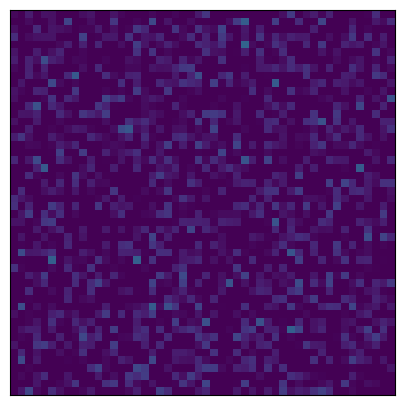

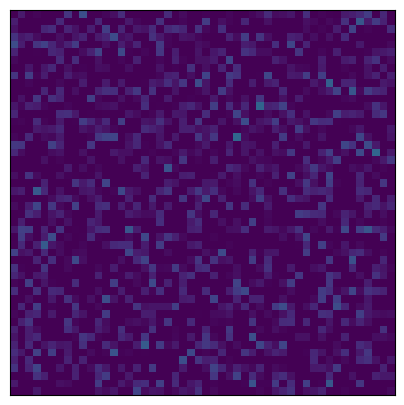

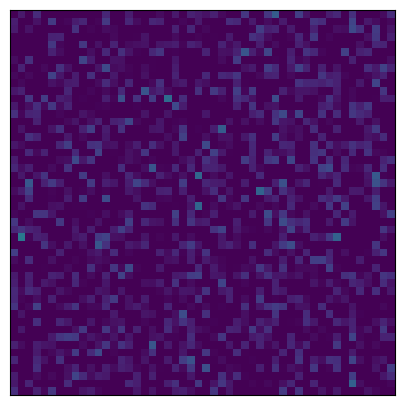

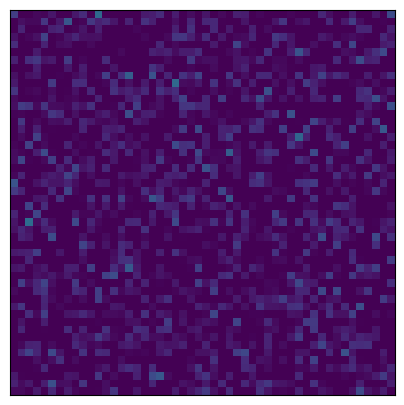

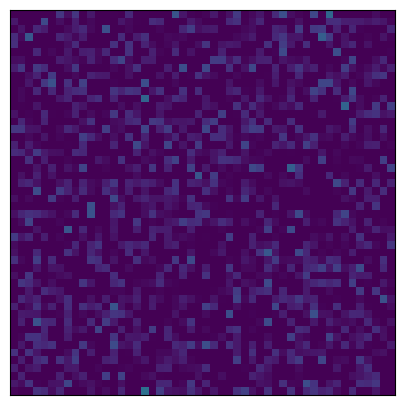

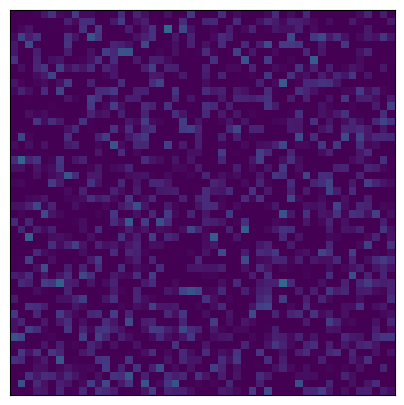

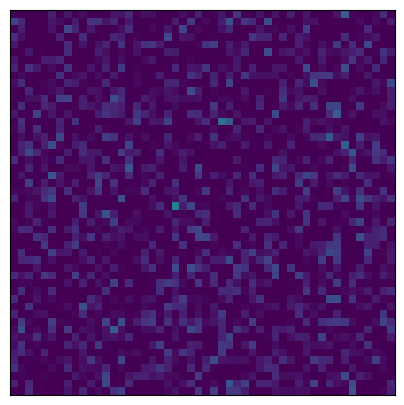

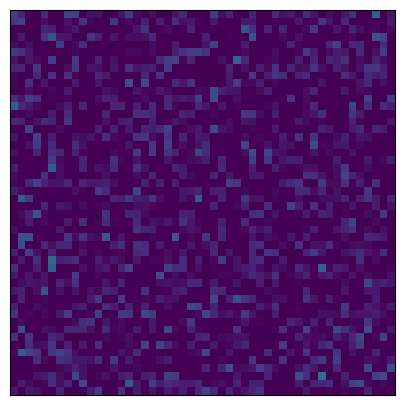

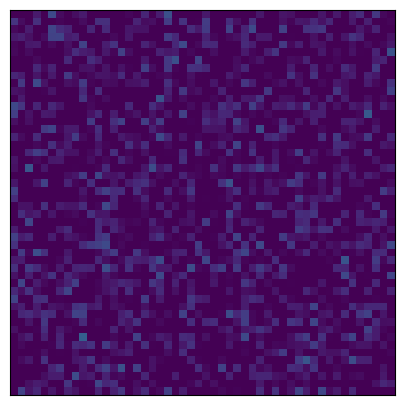

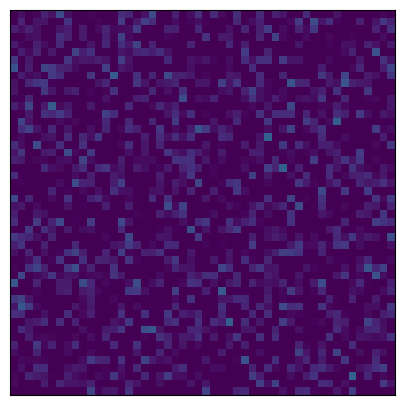

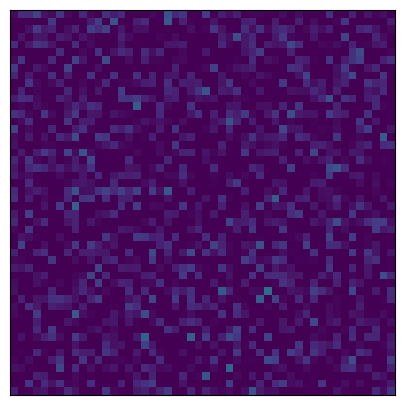

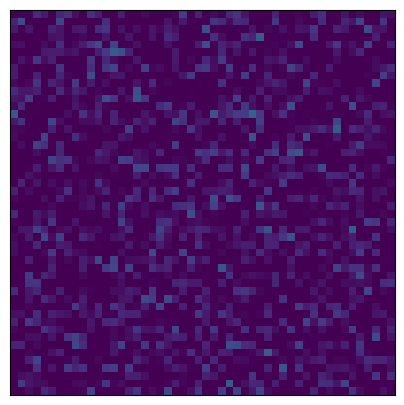

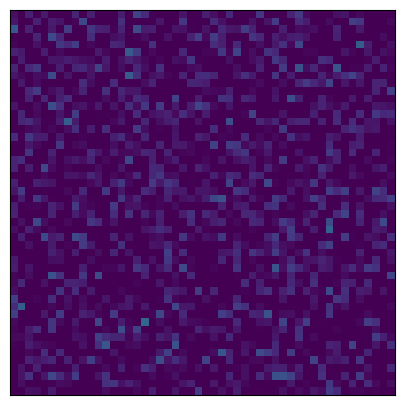

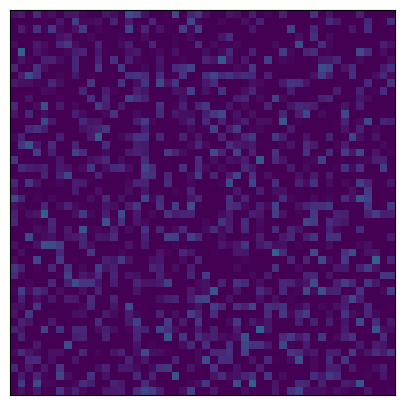

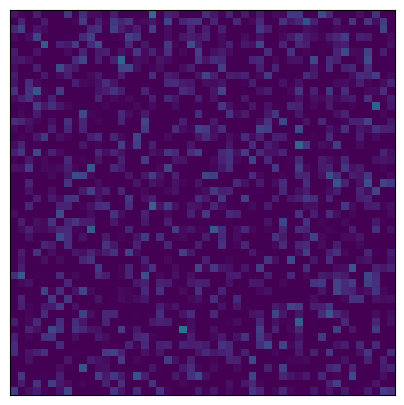

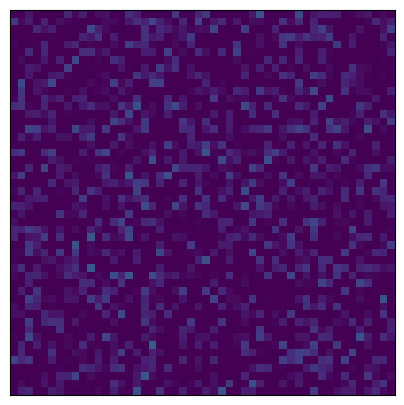

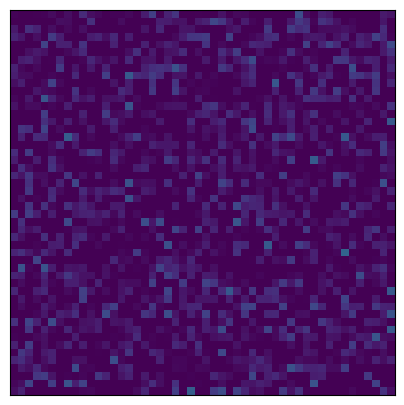

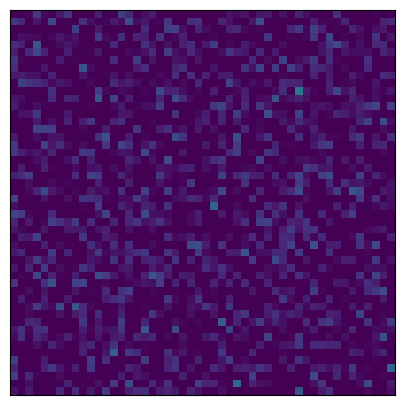

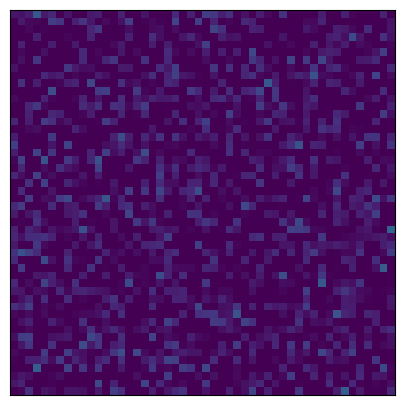

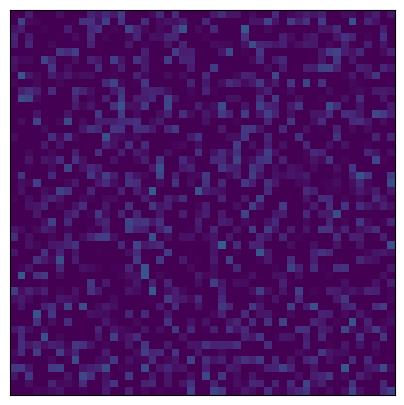

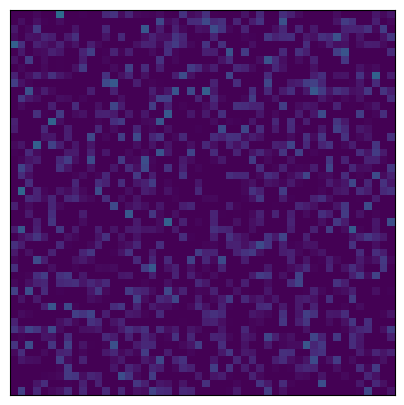

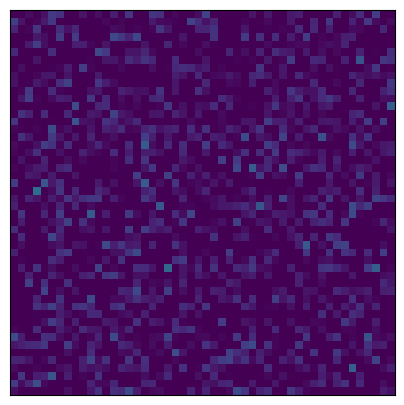

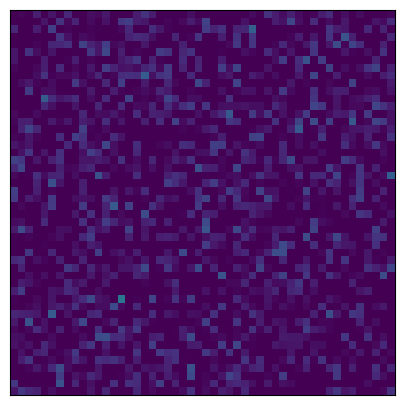

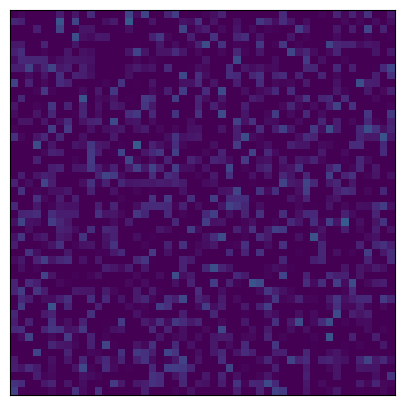

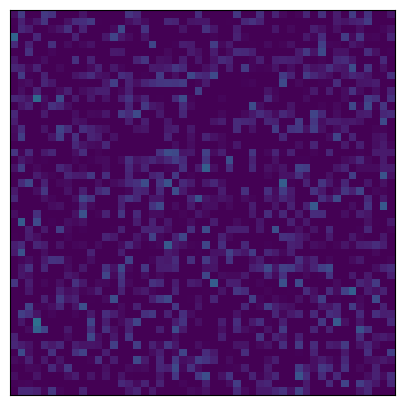

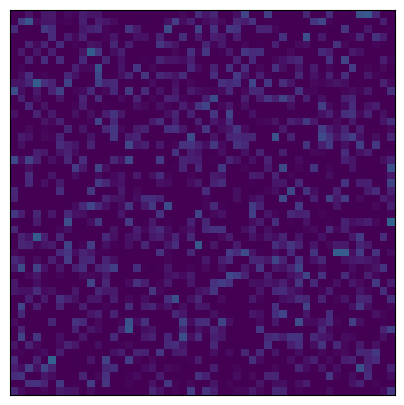

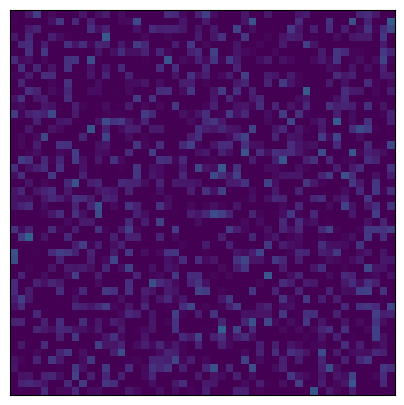

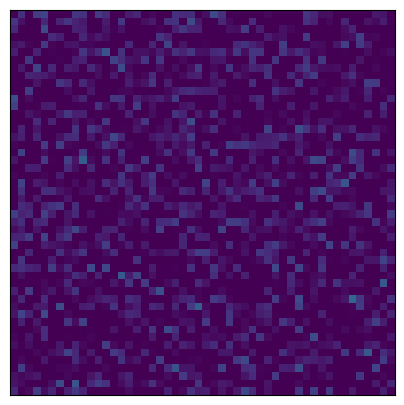

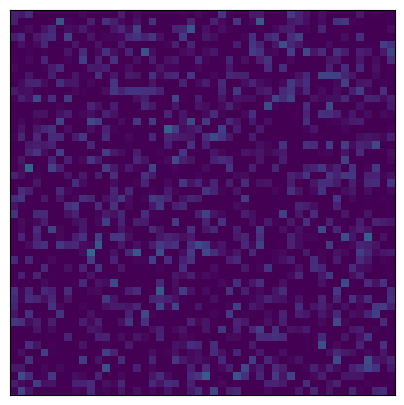

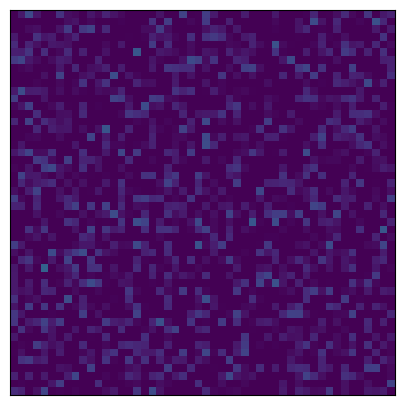

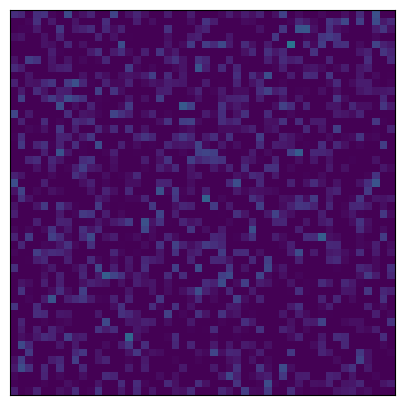

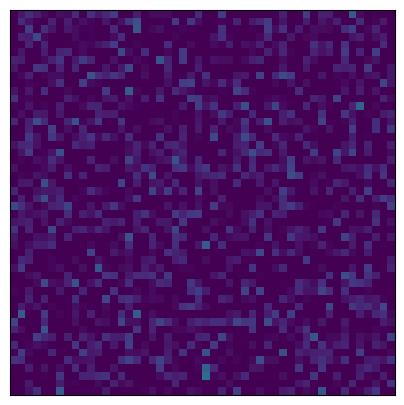

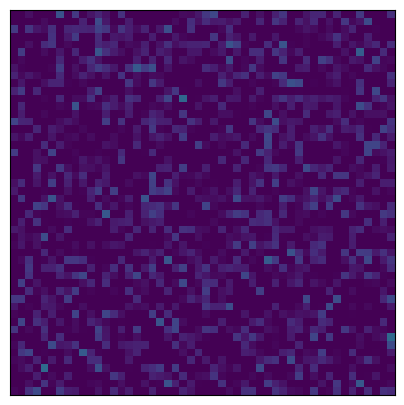

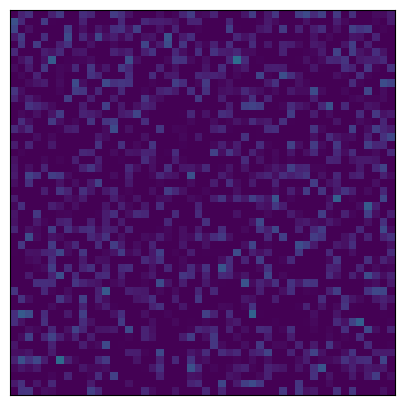

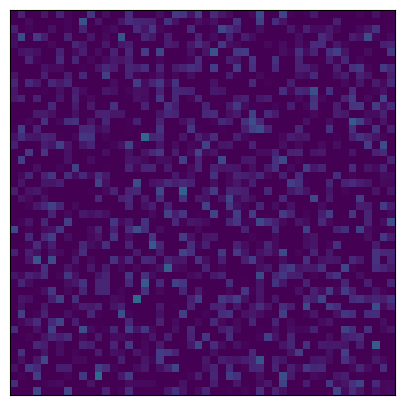

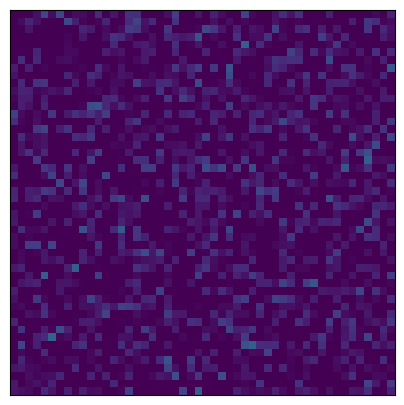

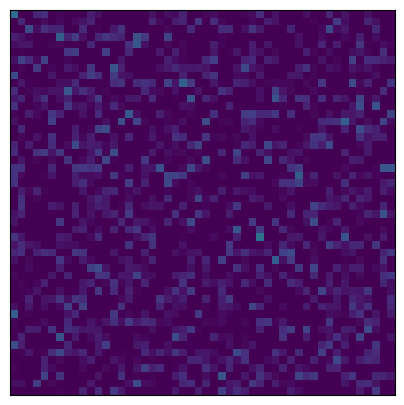

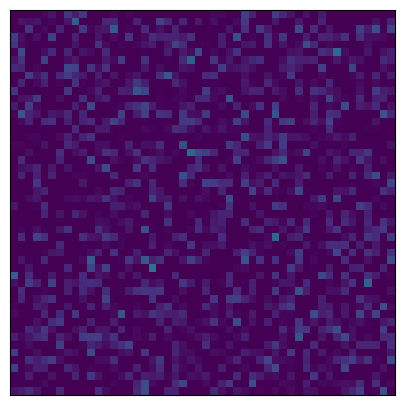

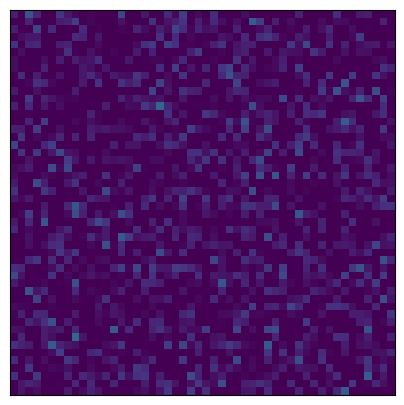

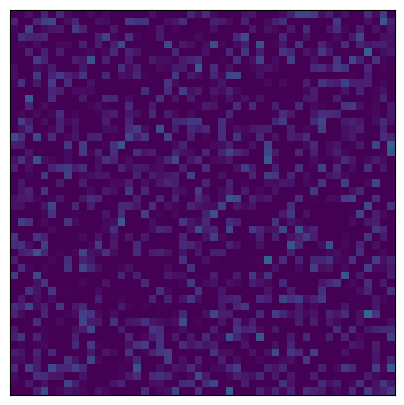

In [101]:
# generates and saves animation frames for the above generated field

for frame in range(t.shape[-1]):
    plt.figure(figsize = (5,5))
    plt.imshow(t[:,:,frame]+n[:,:,frame],vmax = 1,vmin = 0)
    plt.xticks([])
    plt.yticks([])
    plt.show()
    #plt.savefig('example_animation/frame_%d.png' %frame)
    plt.close()